# 00 · 전체 이력 데이터 구성과 신뢰성 점검

**범위:** 게임 데이터가 처음 존재하는 날부터 2026-09-12(KST)까지의 GA4 + Supabase 미러 전체 이력.

**G1 통과 기준:** 원천 범위가 확인되고, 유저 식별키·이벤트 정의·중복·결측·시간대·Supabase 보존기간을 문서화해 이후 통계가 재현 가능해야 한다.

이 노트북은 데이터 신뢰성까지만 다룬다. 모델링이나 이탈 가설 검정은 하지 않는다.

## 1. 분석 원천과 식별키

- 장기 분석 원천은 BigQuery다. Supabase 운영 DB는 약 7일만 보관하므로 신선도 교차검증에만 쓴다.
- GA4 사람/기기 단위 키는 `user_pseudo_id`, 자체 로그는 `client_id`다. 세션마다 달라질 수 있는 익명 `user_id`를 사람 수로 쓰지 않는다.
- `session_logs`는 upsert 이력이 BigQuery에 중복 적재되므로 `session_id`별 최신 `updated_at` 한 행만 쓴다.
- 모든 일자는 KST 기준으로 제한한다.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Markdown, display
from calm_ml import bq, db, report as R, tracking

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'calm_ml').exists():
    ROOT = ROOT / 'ml'
SQL = ROOT / 'sql'
OUT = ROOT / 'reports' / 'g1_data_inventory_2026-09-12'
OUT.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)

## 2. 실행 SQL

쿼리는 아래 파일을 단일 원본으로 삼는다. 이 셀은 실행 전에 SQL 전문을 그대로 표시한다.

In [2]:
sql_files = [
    SQL / 'g1_data_inventory.sql',
    SQL / 'g1_daily_coverage.sql',
    SQL / 'g1_event_inventory.sql',
    SQL / 'g1_supabase_freshness.sql',
    SQL / 'g1_supabase_daily.sql',
]
for path in sql_files:
    display(Markdown(f'### `{path.name}`\n```sql\n{path.read_text(encoding="utf-8")}\n```'))

### `g1_data_inventory.sql`
```sql
-- G1 data reliability: full-history source inventory.
-- Analysis ends at today's KST date. Synthetic/local smoke rows are not removed here:
-- this query measures raw coverage and quality before analytical exclusions.
with ga4 as (
  select
    event_date,
    event_timestamp,
    event_name,
    user_pseudo_id,
    user_id,
    (select value.int_value from unnest(event_params) where key = 'ga_session_id') as ga_session_id
  from `calm-forest.analytics_547127440.events_*`
  where regexp_contains(_table_suffix, r'^\d{8}$')
    and parse_date('%Y%m%d', event_date) <= current_date('Asia/Seoul')
),
session_all as (
  select *
  from `calm-forest.calm_forest_raw.session_logs`
  where date(updated_at, 'Asia/Seoul') <= current_date('Asia/Seoul')
),
session_latest as (
  select *
  from session_all
  qualify row_number() over (
    partition by session_id order by updated_at desc
  ) = 1
)
select
  'GA4 events' as source,
  '행동·유입·기기·지역' as analytical_role,
  count(*) as row_count,
  count(distinct user_pseudo_id) as devices,
  count(distinct user_id) as auth_ids,
  count(distinct if(
    ga_session_id is not null and user_pseudo_id is not null,
    concat(user_pseudo_id, '-', cast(ga_session_id as string)), null
  )) as sessions,
  timestamp_micros(min(event_timestamp)) as first_at,
  timestamp_micros(max(event_timestamp)) as last_at,
  round(100 * safe_divide(countif(user_pseudo_id is null), count(*)), 2) as missing_primary_key_pct,
  cast(0 as int64) as duplicate_rows
from ga4

union all

select
  'BQ game_logs', '좌표·카메라·플레이 표본', count(*),
  count(distinct client_id), count(distinct user_id), count(distinct session_id),
  min(created_at), max(created_at),
  round(100 * safe_divide(countif(client_id is null or client_id = ''), count(*)), 2), 0
from `calm-forest.calm_forest_raw.game_logs`
where date(created_at, 'Asia/Seoul') <= current_date('Asia/Seoul')

union all

select
  'BQ econ_logs', '재화 증감 원장', count(*),
  count(distinct client_id), count(distinct user_id), count(distinct session_id),
  min(created_at), max(created_at),
  round(100 * safe_divide(countif(client_id is null or client_id = ''), count(*)), 2), 0
from `calm-forest.calm_forest_raw.econ_logs`
where date(created_at, 'Asia/Seoul') <= current_date('Asia/Seoul')

union all

select
  'BQ session_logs', '세션 요약·행동 카운트', count(*),
  count(distinct client_id), count(distinct user_id), count(distinct session_id),
  min(started_at), max(updated_at),
  round(100 * safe_divide(countif(client_id is null or client_id = ''), count(*)), 2),
  (select count(*) from session_all) - count(*)
from session_latest

union all

select
  'BQ game_saves', '현재 진행도 스냅샷', count(*),
  cast(null as int64), count(distinct user_id), cast(null as int64),
  cast(null as timestamp), max(updated_at),
  round(100 * safe_divide(countif(user_id is null or user_id = ''), count(*)), 2), 0
from `calm-forest.calm_forest_raw.game_saves`
where date(updated_at, 'Asia/Seoul') <= current_date('Asia/Seoul')

union all

select
  'BQ churn_events', '이탈 개입 점수·실험군', count(*),
  count(distinct client_id), cast(null as int64), count(distinct session_id),
  min(`at`), max(`at`),
  round(100 * safe_divide(countif(client_id is null or client_id = ''), count(*)), 2), 0
from `calm-forest.calm_forest_raw.churn_events`
where date(`at`, 'Asia/Seoul') <= current_date('Asia/Seoul')
order by source;

```

### `g1_daily_coverage.sql`
```sql
-- G1 data reliability: comparable daily device coverage by source.
-- GA4 uses user_pseudo_id; mirrored game/session logs use persistent client_id.
with ga4 as (
  select
    parse_date('%Y%m%d', event_date) as day,
    count(*) as ga4_events,
    count(distinct user_pseudo_id) as ga4_devices
  from `calm-forest.analytics_547127440.events_*`
  where regexp_contains(_table_suffix, r'^\d{8}$')
    and parse_date('%Y%m%d', event_date) <= current_date('Asia/Seoul')
  group by 1
),
game as (
  select
    date(created_at, 'Asia/Seoul') as day,
    count(*) as game_rows,
    count(distinct client_id) as game_devices
  from `calm-forest.calm_forest_raw.game_logs`
  where date(created_at, 'Asia/Seoul') <= current_date('Asia/Seoul')
  group by 1
),
session_latest as (
  select *
  from `calm-forest.calm_forest_raw.session_logs`
  where date(updated_at, 'Asia/Seoul') <= current_date('Asia/Seoul')
  qualify row_number() over (
    partition by session_id order by updated_at desc
  ) = 1
),
sessions as (
  select
    date(started_at, 'Asia/Seoul') as day,
    count(*) as session_count,
    count(distinct client_id) as session_devices
  from session_latest
  group by 1
)
select
  coalesce(ga4.day, game.day, sessions.day) as day,
  coalesce(ga4_events, 0) as ga4_events,
  coalesce(ga4_devices, 0) as ga4_devices,
  coalesce(game_rows, 0) as game_rows,
  coalesce(game_devices, 0) as game_devices,
  coalesce(session_count, 0) as session_count,
  coalesce(session_devices, 0) as session_devices
from ga4
full outer join game using (day)
full outer join sessions using (day)
order by day;

```

### `g1_event_inventory.sql`
```sql
-- G1 data reliability: event taxonomy actually present in GA4.
select
  event_name,
  count(*) as events,
  count(distinct user_pseudo_id) as devices,
  min(parse_date('%Y%m%d', event_date)) as first_day,
  max(parse_date('%Y%m%d', event_date)) as last_day,
  round(100 * safe_divide(countif(user_pseudo_id is null), count(*)), 2) as missing_device_pct
from `calm-forest.analytics_547127440.events_*`
where regexp_contains(_table_suffix, r'^\d{8}$')
  and parse_date('%Y%m%d', event_date) <= current_date('Asia/Seoul')
group by event_name
order by events desc;

```

### `g1_supabase_freshness.sql`
```sql
-- G1 data reliability: hot-store freshness only.
-- Supabase retains roughly seven days, so these counts are never used as full-history totals.
select 'Supabase game_logs' as source, count(*) as row_count,
       count(distinct client_id) as devices, count(distinct session_id) as sessions,
       min(created_at) as first_at, max(created_at) as last_at
from game_logs
union all
select 'Supabase econ_logs', count(*), count(distinct client_id), count(distinct session_id),
       min(created_at), max(created_at)
from econ_logs
union all
select 'Supabase session_logs', count(*), count(distinct client_id), count(distinct session_id),
       min(started_at), max(updated_at)
from session_logs
order by source;

```

### `g1_supabase_daily.sql`
```sql
-- G1 data reliability: KST daily coverage in the seven-day Supabase hot store.
with game as (
  select
    (created_at at time zone 'Asia/Seoul')::date as day,
    count(*) as supabase_game_rows,
    count(distinct client_id) as supabase_game_devices
  from game_logs
  group by 1
),
sessions as (
  select
    (started_at at time zone 'Asia/Seoul')::date as day,
    count(*) as supabase_sessions,
    count(distinct client_id) as supabase_session_devices
  from session_logs
  group by 1
)
select
  coalesce(game.day, sessions.day) as day,
  coalesce(supabase_game_rows, 0) as supabase_game_rows,
  coalesce(supabase_game_devices, 0) as supabase_game_devices,
  coalesce(supabase_sessions, 0) as supabase_sessions,
  coalesce(supabase_session_devices, 0) as supabase_session_devices
from game
full outer join sessions using (day)
order by day;

```

## 3. 원시 결과

BigQuery 전체 이력과 Supabase 핫 스토어를 각각 읽는다. Supabase 수치는 전체 기간 합계가 아니라 최근 운영 상태 확인용이다.

In [3]:
inventory = bq.read_sql_file(SQL / 'g1_data_inventory.sql')
daily = bq.read_sql_file(SQL / 'g1_daily_coverage.sql')
events = bq.read_sql_file(SQL / 'g1_event_inventory.sql')
supabase = db.read_sql((SQL / 'g1_supabase_freshness.sql').read_text(encoding='utf-8'))
supabase_daily = db.read_sql((SQL / 'g1_supabase_daily.sql').read_text(encoding='utf-8'))

inventory.to_csv(OUT / 'inventory.csv', index=False)
daily.to_csv(OUT / 'daily_coverage.csv', index=False)
events.to_csv(OUT / 'event_inventory.csv', index=False)
supabase.to_csv(OUT / 'supabase_freshness.csv', index=False)
supabase_daily.to_csv(OUT / 'supabase_daily.csv', index=False)

display(Markdown('### 원천별 전체 이력'))
display(inventory)
display(Markdown('### GA4 이벤트별 관측량'))
display(events)
display(Markdown('### Supabase 운영 DB 신선도'))
display(supabase)
display(Markdown('### Supabase 최근 일별 커버리지'))
display(supabase_daily)

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


### 원천별 전체 이력

,source,analytical_role,row_count,devices,auth_ids,sessions,first_at,last_at,missing_primary_key_pct,duplicate_rows
0,BQ churn_events,이탈 개입 점수·실험군,1058,31,<NA>,97,2026-09-06 04:11:11.897275+00:00,2026-09-10 14:02:19.360217+00:00,0.00,0
1,BQ econ_logs,재화 증감 원장,2646,251,677,744,2026-08-06 05:52:12.817442+00:00,2026-09-11 16:07:39.160532+00:00,0.00,0
2,BQ game_logs,좌표·카메라·플레이 표본,233520,281,778,937,2026-07-27 04:31:20.183112+00:00,2026-09-11 14:37:25.978374+00:00,1.14,0
3,BQ game_saves,현재 진행도 스냅샷,388,<NA>,388,<NA>,NaT,2026-09-11 16:29:48.182000+00:00,0.00,0
4,BQ session_logs,세션 요약·행동 카운트,645,135,518,645,2026-08-06 04:35:01.593000+00:00,2026-09-11 16:29:05.569000+00:00,0.00,3
5,GA4 events,행동·유입·기기·지역,49108,356,729,716,2026-07-26 16:12:07.358274+00:00,2026-09-11 14:37:36.156861+00:00,0.00,0


...

,event_name,events,devices,first_day,last_day,missing_device_pct
0,session_summary,4790,127,2026-08-06,2026-09-11,0.0
1,chop_tree,4560,75,2026-07-27,2026-09-11,0.0
2,plant_seed,2768,58,2026-07-27,2026-09-11,0.0
3,water_crop,2024,41,2026-07-27,2026-09-11,0.0
4,econ_tx,1992,137,2026-08-06,2026-09-11,0.0
...,...,...,...,...,...,...
135,photo_share,2,2,2026-08-15,2026-09-10,0.0
136,rain_day,2,1,2026-08-06,2026-08-06,0.0
137,photo_upload,2,2,2026-08-15,2026-09-10,0.0
138,weather_event,2,1,2026-08-13,2026-08-13,0.0


### Supabase 운영 DB 신선도

,source,row_count,devices,sessions,first_at,last_at
0,Supabase econ_logs,1622,52,122,2026-09-05 03:10:30.327483+00:00,2026-09-12 06:37:33.693026+00:00
1,Supabase game_logs,136683,55,167,2026-09-04 23:37:19.165577+00:00,2026-09-12 06:42:54.701602+00:00
2,Supabase session_logs,147,44,147,2026-09-05 03:21:31+00:00,2026-09-12 06:42:55.069000+00:00


### Supabase 최근 일별 커버리지

,day,supabase_game_rows,supabase_game_devices,supabase_sessions,supabase_session_devices
0,2026-09-05,16910,10,6,5
1,2026-09-06,10849,6,8,6
2,2026-09-07,4967,4,7,3
3,2026-09-08,1405,6,17,6
4,2026-09-09,34841,16,46,16
5,2026-09-10,38722,24,33,21
6,2026-09-11,21083,13,21,13
7,2026-09-12,7906,10,9,7


## 4. 날짜별 원천 커버리지

서로 다른 식별키이므로 선의 높이가 완전히 같아야 하는 것은 아니다. 다만 특정 날짜 이후 한 원천만 0이 되거나 급격히 벌어지면 계측·적재 단절을 의심한다.

g1_daily_source_device_coverage.png  1287x611px


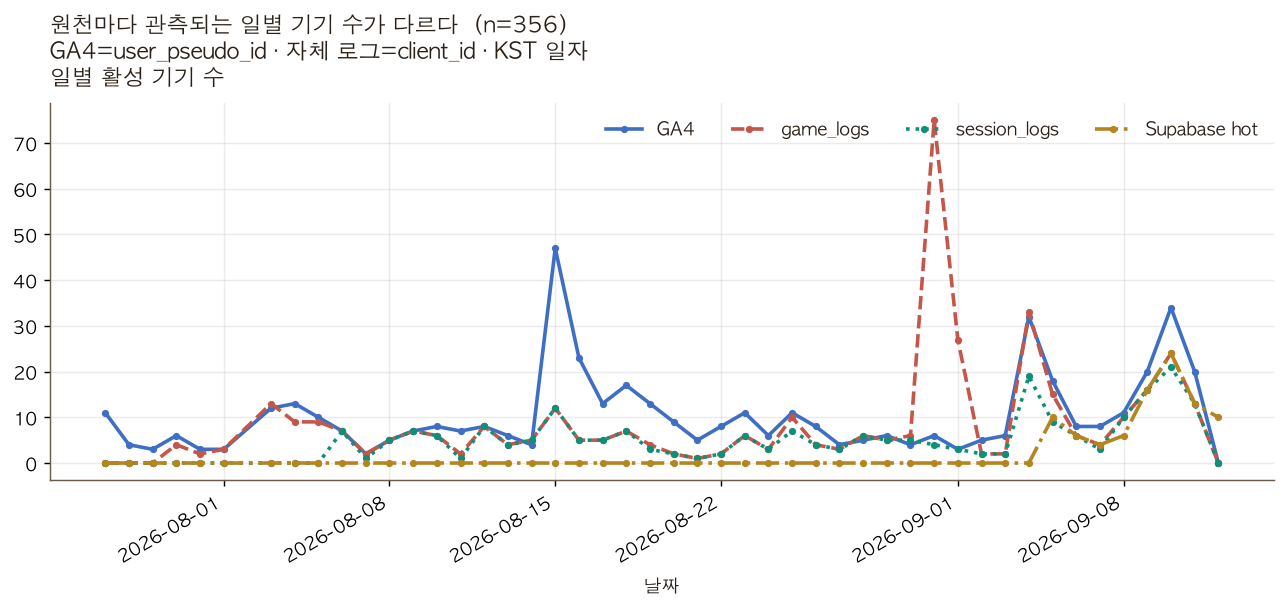

In [4]:
R.setup()
plot_df = daily.merge(supabase_daily, on='day', how='outer').fillna(0).sort_values('day')
plot_df['day'] = pd.to_datetime(plot_df['day'])
ga4_devices = int(inventory.loc[inventory.source == 'GA4 events', 'devices'].iloc[0])
fig, ax = R.new(
    '원천마다 관측되는 일별 기기 수가 다르다',
    ga4_devices,
    sub='GA4=user_pseudo_id · 자체 로그=client_id · KST 일자',
    ylab='일별 활성 기기 수',
    figsize=(10, 4.8),
)
series = [
    ('GA4', 'ga4_devices', R.PALETTE[1], '-'),
    ('game_logs', 'game_devices', R.PALETTE[0], '--'),
    ('session_logs', 'session_devices', R.PALETTE[2], ':'),
    ('Supabase hot', 'supabase_game_devices', R.PALETTE[3], '-.'),
]
for label, col, color, linestyle in series:
    ax.plot(plot_df['day'], plot_df[col], label=label, color=color,
            linestyle=linestyle, linewidth=2, marker='o', markersize=3)
ax.legend(frameon=False, ncol=4, loc='upper right')
ax.set_xlabel('날짜')
ax.spines[['top', 'right']].set_visible(False)
fig.autofmt_xdate(rotation=30, ha='right')
fig.tight_layout()
chart = R.save(fig, ax, 'g1_daily_source_device_coverage')
print(R.check(chart))
display(R.show(chart))

## 5. 재현 기록

표본 수, 중복 수, 그래프를 W&B의 `calm-forest` 프로젝트 안 `g1-full-history-inventory` 런에 남긴다. 개인별 원시 로그는 올리지 않고 집계 통계와 PNG만 기록한다.

In [5]:
existing_run = OUT / 'wandb_run_id.txt'
ga4_row = inventory.loc[inventory.source == 'GA4 events'].iloc[0]
session_row = inventory.loc[inventory.source == 'BQ session_logs'].iloc[0]
if existing_run.exists():
    run_id = existing_run.read_text().strip()
    with tracking.wandb.init(project=tracking.PROJECT, id=run_id, resume='must') as run:
        run.log({'daily_source_device_coverage': tracking.wandb.Image(str(chart))})
    print(f'기존 W&B run 갱신: {run_id}')
else:
    with tracking.start_run(
        'g1-full-history-inventory', tags=['gate'],
        config={'through_kst': '2026-09-12', 'primary_identity': 'device'},
    ) as run:
        run.summary['ga4_events'] = int(ga4_row.row_count)
        run.summary['ga4_devices'] = int(ga4_row.devices)
        run.summary['dedup_sessions'] = int(session_row.sessions)
        run.summary['session_duplicate_rows'] = int(session_row.duplicate_rows)
        run.log({'daily_source_device_coverage': tracking.wandb.Image(str(chart))})
        existing_run.write_text(run.id, encoding='utf-8')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb: Currently logged in as: icucheol to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: setting up run ke113ugz


wandb: Tracking run with wandb version 0.28.2


wandb: Run data is saved locally in /Users/uicheol_hwang/calm_forest/ml/notebooks/wandb/run-20260912_175038-ke113ugz
wandb: Run `wandb offline` to turn off syncing.


...

wandb: uploading history steps 1-1, summary


wandb: 
wandb: Run summary:
wandb:         dedup_sessions 645
wandb:            ga4_devices 356
wandb:             ga4_events 49108
wandb: session_duplicate_rows 3
wandb: 


wandb: 🚀 View run g1-full-history-inventory at: https://wandb.ai/icucheol/calm-forest/runs/ke113ugz
wandb: ⭐️ View project at: https://wandb.ai/icucheol/calm-forest
wandb: Synced 4 W&B file(s), 1 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260912_175038-ke113ugz/logs


기존 W&B run 갱신: ke113ugz


## 6. 한 줄 답과 G1 판정

**게임 데이터의 장기 분석 기반은 마련돼 있다. 2026-07-27부터 2026-09-11까지는 BigQuery 전체 이력, 2026-09-12 자체 로그는 Supabase 핫 스토어로 확인된다. G1은 제한부 통과다.**

### 데이터 구성요소와 현재 규모

| 원천 | 현재 관측 규모 | 분석 역할 |
|---|---:|---|
| GA4 | 이벤트 49,108건 · 기기 356대 · 세션 716개 · 이벤트 유형 140개 | 행동, 유입, 기기, 지역, 퍼널 |
| BQ `game_logs` | 표본 233,520행 · 기기 281대 · 세션 937개 | 이동 좌표, 카메라, 플레이 동선 |
| BQ `econ_logs` | 거래 2,646건 · 기기 251대 · 세션 744개 | 재화 획득·소비 원장 |
| BQ `session_logs` | 최신 세션 645개 · 기기 135대 | 세션 요약, 행동 카운트 |
| BQ `game_saves` | 저장 상태 388개 | 현재 진행도 스냅샷 |
| BQ `churn_events` | 점수 1,058건 · 기기 31대 · 세션 97개 | 개입 점수와 실험군 |

### 데이터 신뢰성에서 확인한 것

- GA4 `user_pseudo_id` 결측은 0%다. 반면 `user_id`는 729개로 기기 356대보다 2.0배 많다. 익명 ID 재발급 때문에 `user_id`를 사람 수로 쓰면 안 된다는 기존 경고가 실측으로 다시 확인됐다.
- `game_logs.client_id` 결측은 1.14%다. 초기 계측 이전 행이 섞여 있으므로 기기 단위 분석에서는 제외 사유와 규모를 항상 병기한다.
- `session_logs`는 원본 648행 중 중복 이력 3행을 제거하면 645세션이다. 이후 쿼리는 최신행 dedupe를 기본으로 둔다.
- 장기 데이터의 마지막 시각은 9월 11일이고, Supabase 마지막 자체 로그는 9월 12일 15:42 KST다. 자체 로그는 오늘도 살아 있지만 일일 BigQuery 적재에는 하루 시차가 있다.
- 9월 12일 GA4 daily/intraday 테이블은 아직 없다. 따라서 오늘 행동 이벤트까지 포함한 GA4 통계는 지금 시점에는 만들 수 없다.

### 분석에 필요한 표준 구성

이후 분석 표는 `client_id/user_pseudo_id` 기기 축, KST 날짜 축, dedupe된 세션 축, GA4 행동 이벤트 축, 경제 원장 축, 진행도 스냅샷 축으로 나눈다. 서로 다른 기기 키를 직접 같다고 두지 않고, 연결이 필요한 분석은 검증된 매핑 또는 세션·시간 조건을 별도로 정의한다.

## 7. 이 숫자로 말할 수 없는 것

- GA4 `user_pseudo_id`와 자체 로그 `client_id`는 같은 값이 아니므로 단순 행 조인하지 않는다.
- 원천별 기기 수 차이는 누락일 수도 있지만, 동의·차단·로딩 순서·식별자 생성 시점 차이일 수도 있다.
- 개발자·자동 테스트·유급 베타테스터가 섞여 있다. 이번 G1은 오염 규모를 숨기지 않기 위해 원천 합계에서 제외하지 않았다.
- 오늘 GA4 일별 export가 아직 없으면 최신일은 어제로 보인다. 실시간 intraday는 별도 점검 대상이다.

다음 게이트에서는 사용자 승인 뒤 이벤트·세션·진행도 분포를 EDA한다.